In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
DATASET_PATH = 'dataset'
classes = os.listdir(DATASET_PATH)

print("Total Classes:", len(classes))

Total Classes: 25


In [4]:
class_counts = {}
total_images = 0

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        class_counts[cls] = count
        total_images += count

print("Total Images:", total_images)

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

Total Images: 31996
Apple___Apple_scab: 713
Apple___healthy: 1724
Blueberry___healthy: 1608
Cherry_healthy: 901
Corn_healthy: 1162
Corn__Commonrust: 1299
Corn__Grayleafspot: 576
Corn__LeafBlight: 1167
Grape___Black_rot: 1251
Grape___healthy: 486
PepperBell___Bacterialspot: 1071
PepperBell___healthy: 1512
Potato___Early_blight: 1112
Potato___Late_blight: 1200
Soyabean___healthy: 2154
Squash___Powdery_mildew: 2017
Strawberry___healthy: 544
Tomato___Bacterial_spot: 2228
Tomato___Early_blight: 1079
Tomato___healthy: 1635
Tomato___Late_blight: 2010
Tomato___LeafMold: 1037
Tomato___mosaicvirus: 417
Tomato___Septorialeafspot: 1916
Tomato___YellowLeafCurlVirus: 1177


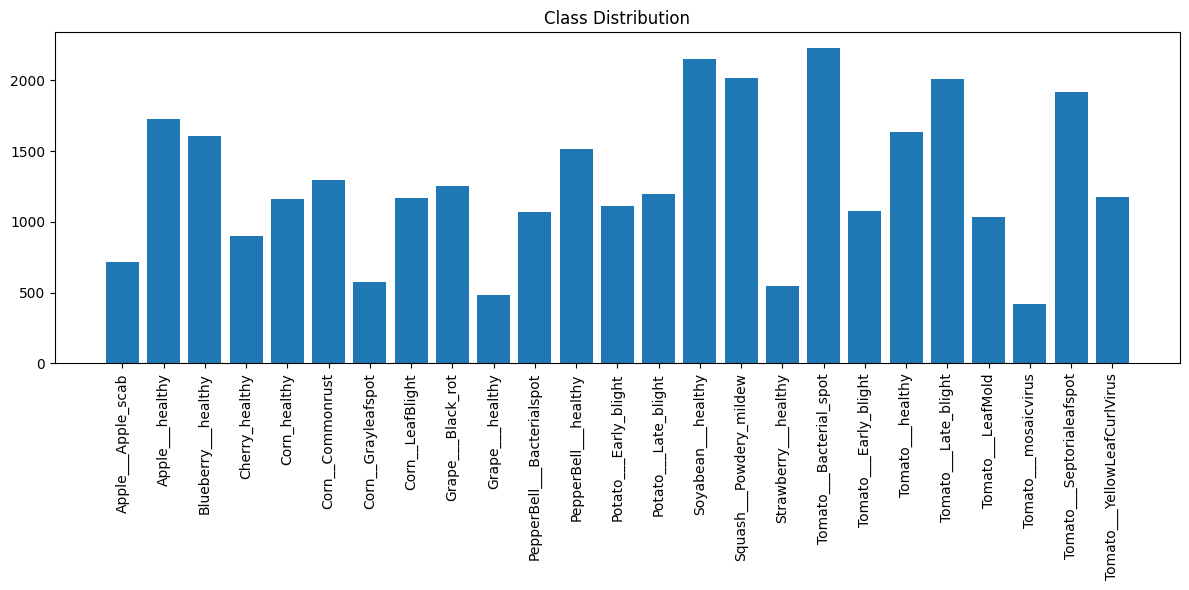

In [5]:
plt.figure(figsize=(12,6))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

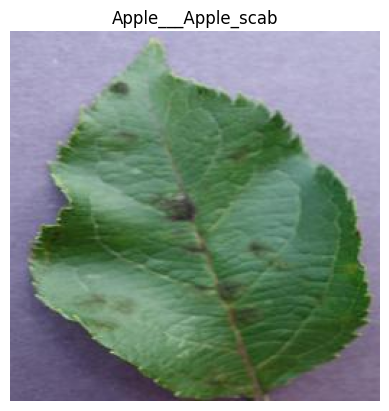

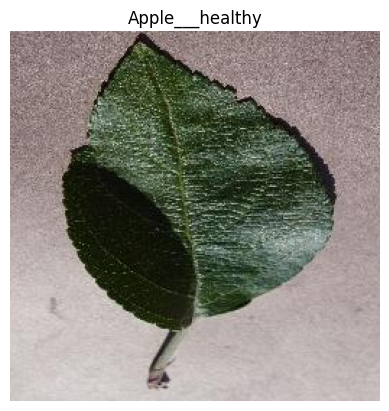

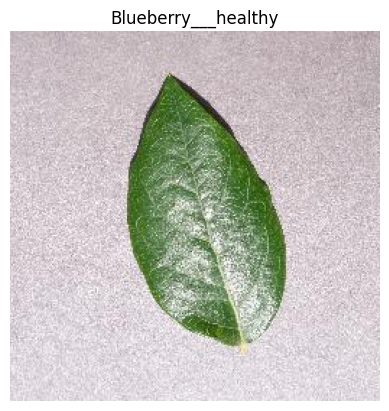

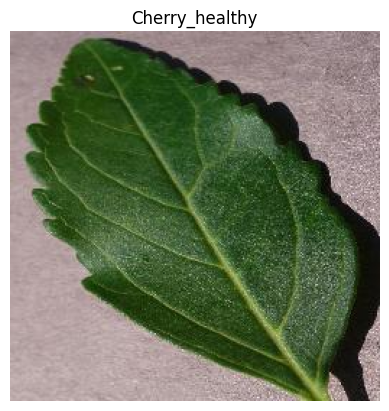

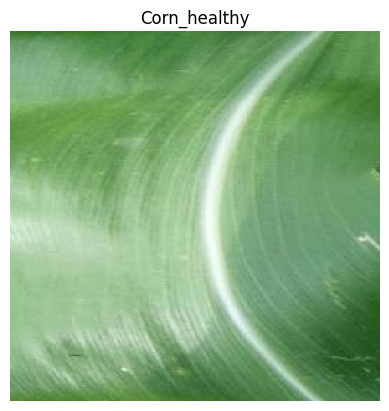

In [ ]:
for cls in classes[:]:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = os.listdir(cls_path)

    if images:
        img_path = os.path.join(cls_path, images[0])
        img = Image.open(img_path)
        
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')
        plt.show()


In [9]:
import os
from PIL import Image

invalid_images = []

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        
        try:
            img = Image.open(img_path)
            img.verify()   # check corruption
        except:
            invalid_images.append(img_path)

print("Invalid Images:", len(invalid_images))

Invalid Images: 0


In [10]:
sizes = []

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    
    for img_name in os.listdir(cls_path)[:20]:  # sample check
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)
        sizes.append(img.size)

print("Sample Image Sizes:", sizes[:10])

Sample Image Sizes: [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]


In [11]:
import numpy as np

counts = list(class_counts.values())

print("Min images in class:", np.min(counts))
print("Max images in class:", np.max(counts))
print("Average images:", np.mean(counts))

Min images in class: 417
Max images in class: 2228
Average images: 1279.84


In [13]:
for cls, count in class_counts.items():
    if count < 100:
        print(f"⚠️ Low data class: {cls} → {count} images")

In [14]:
import hashlib

hashes = {}
duplicates = []

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        
        with open(img_path, 'rb') as f:
            filehash = hashlib.md5(f.read()).hexdigest()
            
            if filehash in hashes:
                duplicates.append(img_path)
            else:
                hashes[filehash] = img_path

print("Duplicate Images:", len(duplicates))

Duplicate Images: 203


In [15]:
print("===== DATASET HEALTH REPORT =====")

print("Total Classes:", len(classes))
print("Total Images:", total_images)
print("Invalid Images:", len(invalid_images))
print("Duplicate Images:", len(duplicates))

if len(invalid_images) == 0:
    print("✅ No corrupted images")

if len(duplicates) == 0:
    print("✅ No duplicate images")

print("================================")

===== DATASET HEALTH REPORT =====
Total Classes: 25
Total Images: 31996
Invalid Images: 0
Duplicate Images: 203
✅ No corrupted images


In [16]:
import os

removed = 0

for dup in duplicates:
    try:
        os.remove(dup)
        removed += 1
    except:
        pass

print("Removed duplicates:", removed)

Removed duplicates: 203


In [17]:
print("Duplicate Images:", len(duplicates))


Duplicate Images: 203


In [19]:
import os
import hashlib

DATASET_PATH = 'dataset'

hash_dict = {}
duplicates_removed = 0

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    
    if not os.path.isdir(cls_path):
        continue
    
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        
        try:
            with open(img_path, 'rb') as f:
                filehash = hashlib.md5(f.read()).hexdigest()
            
            if filehash in hash_dict:
                # Duplicate found → REMOVE
                os.remove(img_path)
                duplicates_removed += 1
            else:
                hash_dict[filehash] = img_path
                
        except:
            pass

print("✅ Duplicates Removed:", duplicates_removed)

✅ Duplicates Removed: 0


In [20]:
print("Checking duplicates again...")

hashes = set()
duplicates = 0

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        
        try:
            with open(img_path, 'rb') as f:
                filehash = hashlib.md5(f.read()).hexdigest()
            
            if filehash in hashes:
                duplicates += 1
            else:
                hashes.add(filehash)
        except:
            pass

print("Remaining duplicates:", duplicates)

Checking duplicates again...
Remaining duplicates: 0
